## **TECHNICAL NOTE: DATA REDUCTION**

##### Aggregation as a Data Reduction Technique

In [2]:
import pandas as pd
import numpy as np

np.random.seed(123)

customer_id = np.random.choice(np.arange(1,4), size=100, replace=True)
date = np.random.choice(pd.date_range(start="2023-01-01", periods=30, freq="D"), size=100, replace=True)
amount = np.random.uniform(low=5, high=100, size=100).round(2)

df = pd.DataFrame({
    "customer_id": customer_id,
    "date": date,
    "amount": amount
})

df.head(10)

,customer_id,date,amount
0,3,2023-01-13,24.73
1,2,2023-01-23,32.79
2,3,2023-01-28,54.40
3,3,2023-01-07,90.68
4,1,2023-01-18,98.44
5,3,2023-01-30,29.47
6,3,2023-01-15,58.61
7,2,2023-01-11,81.66
8,3,2023-01-04,42.47
9,2,2023-01-21,74.45


In [2]:
df_summary = df.groupby("customer_id").agg(
    total_spend = ("amount", "sum"),
    avg_spend = ("amount", "mean"),
    transaction_count = ("amount", "count"),
)
df_summary

,total_spend,avg_spend,transaction_count
customer_id,,,
1,1826.25,60.875000,30
2,1686.06,52.689375,32
3,1775.56,46.725263,38


##### Sampling as a Data Reduction Technique

In [3]:
np.random.seed(123)

# Simulate a large dataset

large_data = pd.DataFrame({
    "id": np.arange(1,100001),
    "income": np.random.normal(loc=30000, scale=5000, size=100000).round(2),
    "churn": np.random.choice([0,1], size=100000, replace=True, p=[0.9,0.1]),
    "region": np.random.choice(["North", "South", "East", "West"], size=100000, replace=True),
    "signup_order": np.random.choice(np.arange(1,100001), size=100000, replace=False)
})

large_data

,id,income,churn,region,signup_order
0,1,24571.85,1,South,50229
1,2,34986.73,1,South,28721
2,3,31414.89,0,South,23815
3,4,22468.53,1,North,50503
4,5,27107.00,0,North,78148
...,...,...,...,...,...
99995,99996,27966.97,0,South,44832
99996,99997,34666.25,0,West,30947
99997,99998,35794.17,1,North,77417
99998,99999,41418.73,1,East,92352


In [4]:
large_data['churn'].value_counts(normalize=True)

churn
0    0.90031
1    0.09969
Name: proportion, dtype: float64

**1. Simple Random Sampling**

In [5]:
sample_simple = large_data.sample(frac=0.10)
sample_simple

,id,income,churn,region,signup_order
43932,43933,32937.70,0,South,20986
79848,79849,38722.03,0,North,22332
83777,83778,27989.32,0,South,44547
60031,60032,30247.27,0,North,46545
15801,15802,41235.72,0,West,58289
...,...,...,...,...,...
16638,16639,24187.41,0,South,77488
8413,8414,31114.92,1,West,15899
12460,12461,26054.60,0,South,41816
69447,69448,33736.40,0,South,14394


In [6]:
sample_simple['churn'].value_counts(normalize=True)

churn
0    0.8996
1    0.1004
Name: proportion, dtype: float64

**2. Stratified Sampling**

In [7]:
from sklearn.model_selection import train_test_split

sample_stratified = train_test_split(
    large_data, test_size=0.10, stratify=large_data['churn'], random_state=42
)

# Check class balance in sample
large_data['churn'].value_counts(normalize=True)

churn
0    0.90031
1    0.09969
Name: proportion, dtype: float64

In [8]:
sample_simple['churn'].value_counts(normalize=True)

churn
0    0.8996
1    0.1004
Name: proportion, dtype: float64

**3. Systematic Sampling**

In [9]:
# Select every 10-th row
sample_systematic = large_data.sort_values('signup_order').iloc[::10]

sample_systematic['churn'].value_counts(normalize=True)

churn
0    0.9022
1    0.0978
Name: proportion, dtype: float64

**4. Cluster Sampling**

In [10]:
np.random.seed(42)

selected_regions = np.random.choice(large_data['region'].unique(), size=2)
sample_cluster = large_data[large_data['region'].isin(selected_regions)]

sample_cluster['region'].value_counts(normalize=True)

region
West    0.501133
East    0.498867
Name: proportion, dtype: float64

In [11]:
sample_cluster['churn'].value_counts(normalize=True)

churn
0    0.899034
1    0.100966
Name: proportion, dtype: float64

##### Principal Component Analysis (PCA)

Data import

In [3]:
toothpaste = pd.read_csv("../Datasets/toothpaste_intent.csv")

# View th data
toothpaste.head(10)

,Participant,X1,X2,X3,X4,X5,X6,purchase_intent
0,1,7,3,6,4,2,4,36.969209
1,2,1,3,2,4,5,4,68.865419
2,3,6,2,7,4,1,3,30.806181
3,4,4,5,4,6,2,5,45.585134
4,5,1,2,2,3,6,2,80.794320
5,6,6,3,6,4,2,4,32.847697
6,7,5,3,6,3,4,3,52.704074
7,8,6,4,7,4,1,4,25.944001
8,9,3,4,2,3,6,3,79.764049
9,10,2,6,2,6,7,6,69.484635


In [13]:
toothpaste.describe()

,Participant,X1,X2,X3,X4,X5,X6,purchase_intent
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,15.500000,3.933333,3.900000,4.100000,4.100000,3.500000,4.166667,50.342934
std,8.803408,1.981524,1.373392,2.056948,1.373392,1.907336,1.391683,19.268087
min,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,2.000000,10.490984
25%,8.250000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,37.244991
50%,15.500000,4.000000,4.000000,4.000000,4.000000,3.500000,4.000000,46.598796
75%,22.750000,6.000000,5.000000,6.000000,5.000000,5.000000,4.750000,68.487991
max,30.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,82.825842


Correlation matrix and heatmap

In [14]:
M = toothpaste.iloc[:, 1:7].corr().round(3).astype(str)

mask = np.triu(np.ones(M.shape), k=1).astype(bool)
M.values[mask] = ""
M = pd.DataFrame(M)
M

,X1,X2,X3,X4,X5,X6
X1,1.0,,,,,
X2,-0.053,1.0,,,,
X3,0.873,-0.155,1.0,,,
X4,-0.086,0.572,-0.248,1.0,,
X5,-0.858,0.02,-0.778,-0.007,1.0,
X6,0.004,0.64,-0.018,0.64,-0.136,1.0


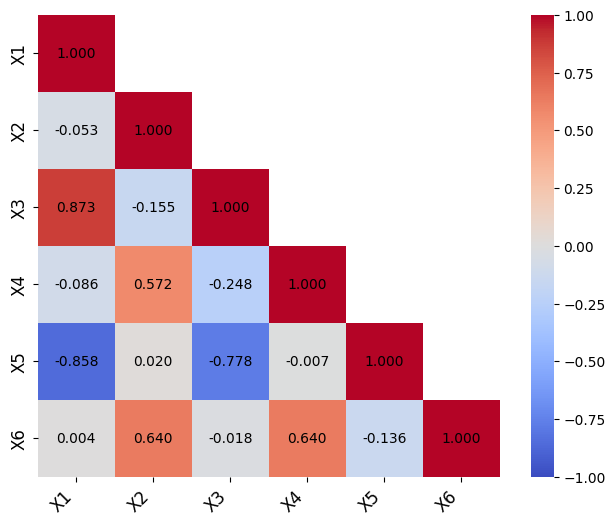

In [15]:
M = toothpaste.iloc[:, 1:7].corr().round(3)
mask = np.triu(np.ones_like(M, dtype=bool), k=1)
M = M.mask(mask)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(
    M,
    mask=mask,
    annot=True,          # mostrar coeficientes
    fmt=".3f",           # 3 decimales
    cmap="coolwarm",     # paleta similar a corrplot
    vmin=-1, vmax=1,
    square=True,
    cbar=True,
    annot_kws={"size": 10, "color": "black"}
)
plt.xticks(rotation=45, ha="right", fontsize=12, color="black")
plt.yticks(fontsize=12, color="black")
plt.show()

Standardize Data

In [16]:
from sklearn.preprocessing import StandardScaler

toothpaste_std = pd.DataFrame(StandardScaler().fit_transform(toothpaste.iloc[:, 1:7]), columns=['X1','X2','X3','X4','X5','X6'])
toothpaste_std.head(6)

,X1,X2,X3,X4,X5,X6
0,1.574088,-0.666514,0.939490,-0.074057,-0.799882,-0.121806
1,-1.505649,-0.666514,-1.038383,-0.074057,0.799882,-0.121806
2,1.060798,-1.407086,1.433958,-0.074057,-1.333136,-0.852645
3,0.034219,0.814629,-0.049447,1.407086,-0.799882,0.609032
4,-1.505649,-1.407086,-1.038383,-0.814629,1.333136,-1.583483
5,1.060798,-0.666514,0.939490,-0.074057,-0.799882,-0.121806


In [17]:
toothpaste_std.describe().round(5)

,X1,X2,X3,X4,X5,X6
count,30.00000,30.00000,30.00000,30.00000,30.00000,30.00000
mean,0.00000,0.00000,0.00000,0.00000,0.00000,-0.00000
std,1.01710,1.01710,1.01710,1.01710,1.01710,1.01710
min,-1.50565,-1.40709,-1.53285,-1.55520,-1.33314,-1.58348
25%,-0.99236,-0.66651,-1.03838,-0.81463,-0.79988,-0.85264
50%,0.03422,0.07406,-0.04945,-0.07406,0.00000,-0.12181
75%,1.06080,0.81463,0.93949,0.66651,0.79988,0.42632
max,1.57409,2.29577,1.43396,2.14766,1.86639,2.07071


Run PCA

In [18]:
from sklearn.decomposition import PCA

pca = PCA()
pca_model = pca.fit(toothpaste_std)

stdev = np.sqrt(pca.explained_variance_).round(4)
Prvar = pca.explained_variance_ratio_.round(4)
Cuprop = np.cumsum(pca.explained_variance_ratio_.round(4))

pd.DataFrame({
    "Standard deviation": stdev,
    "Proportion of Variance": Prvar,
    "Cumulative Proportion": Cuprop
}, index=[f"PC{i+1}" for i in range(len(stdev))]).T


,PC1,PC2,PC3,PC4,PC5,PC6
Standard deviation,1.6809,1.5148,0.6759,0.5942,0.4347,0.2969
Proportion of Variance,0.4552,0.3697,0.0736,0.0569,0.0304,0.0142
Cumulative Proportion,0.4552,0.8249,0.8985,0.9554,0.9858,1.0000


Scree plot & Explained variance

In [19]:
# 1. Correlation matrix
M = toothpaste.iloc[:, 1:7].corr()

# 2. Extract eigenvalues
EV = np.sort(np.linalg.eigvals(M))[::-1]
EV

array([2.73118833, 2.21811927, 0.44159791, 0.34125765, 0.18262823,
       0.08520861])

In [20]:
# 3. Individual variance explained (each EV / total variance)
prop_var = EV/len(EV)
prop_var

array([0.45519806, 0.36968654, 0.07359965, 0.05687627, 0.03043804,
       0.01420144])

In [21]:
# 4. Cumulative variance explained
cum_var = prop_var.cumsum()
cum_var

array([0.45519806, 0.8248846 , 0.89848425, 0.95536053, 0.98579856,
       1.        ])

**Variance explained based on the model**

In [22]:
eigenvalues = (np.sqrt(pca.explained_variance_))**2
eigenvalues

array([2.82536724, 2.29460614, 0.45682543, 0.35302515, 0.18892576,
       0.08814684])

In [23]:
prop_var = eigenvalues / eigenvalues.sum()
prop_var.cumsum()

array([0.45519806, 0.8248846 , 0.89848425, 0.95536053, 0.98579856,
       1.        ])

**1. Scree plot**

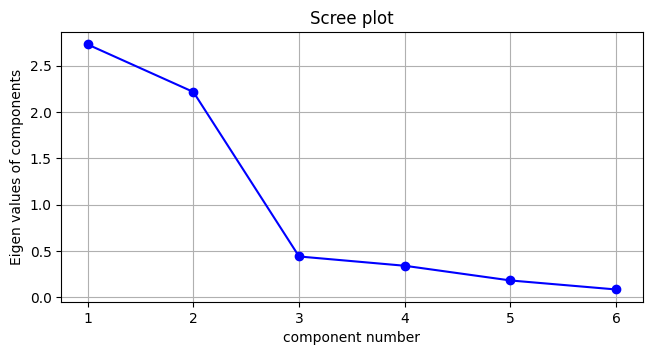

In [24]:
plt.figure(figsize=(7.5,3.5))
plt.plot(range(1, len(EV)+1), EV, 'o-', color='blue')
plt.title("Scree plot")
plt.xlabel("component number")
plt.ylabel("Eigen values of components")
plt.grid(True)
plt.show()

**2. Cumulative Variance Explained**

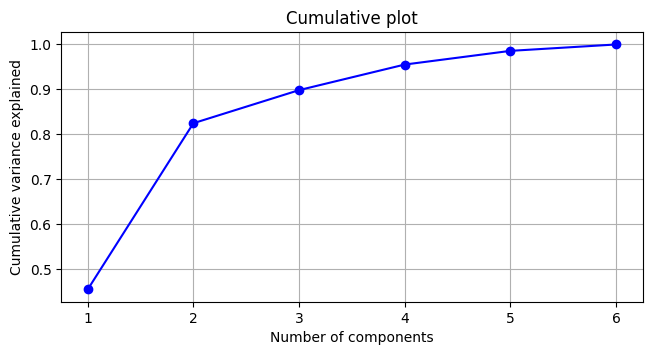

In [25]:
plt.figure(figsize=(7.5, 3.5))
plt.plot(range(1, len(cum_var)+1), cum_var, 'o-', color='blue')
plt.title("Cumulative plot")
plt.xlabel("Number of components")
plt.ylabel("Cumulative variance explained")
plt.grid(True)
plt.show()

##### PCA Loadings and Component Interpretation

In [26]:
comp = pca_model.components_.round(3).T
pd.DataFrame(comp, columns=[f"PC{i+1}" for i in range(len(comp))])

,PC1,PC2,PC3,PC4,PC5,PC6
0,0.562,0.170,-0.012,-0.244,0.171,0.753
1,-0.182,0.534,0.691,-0.437,-0.062,-0.102
2,0.566,0.088,0.158,0.159,0.590,-0.523
3,-0.207,0.530,-0.682,-0.347,0.264,-0.149
4,-0.526,-0.236,0.179,0.040,0.741,0.293
5,-0.107,0.585,0.039,0.776,-0.022,0.205


In [27]:
load1 = pca_model.components_.round(3).T[:, 0:2]
loadings_df = pd.DataFrame(load1, columns=[f"PC{i+1}" for i in range(load1.shape[1])])
loadings_df['Variable'] = [f"X{i+1}" for i in range(len(loadings_df))]
loadings_df


,PC1,PC2,Variable
0,0.562,0.170,X1
1,-0.182,0.534,X2
2,0.566,0.088,X3
3,-0.207,0.530,X4
4,-0.526,-0.236,X5
5,-0.107,0.585,X6


In [33]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


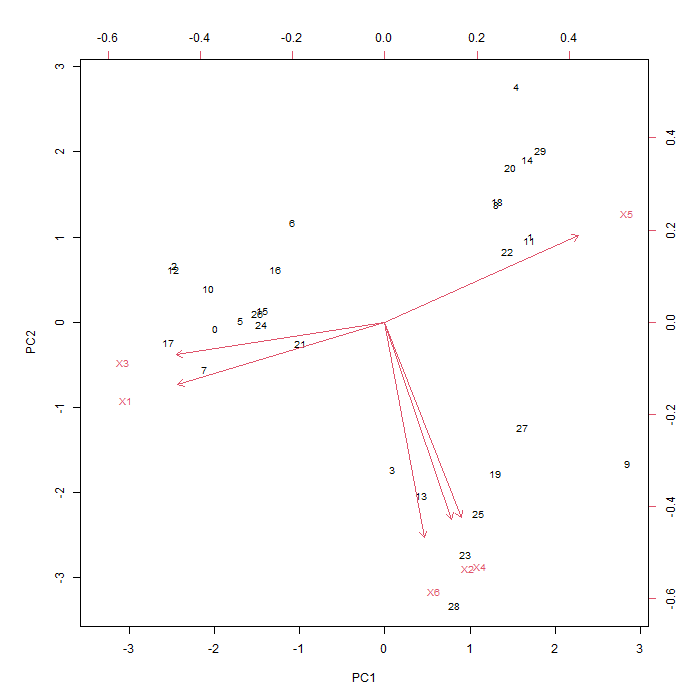

In [35]:
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri, conversion
from IPython.display import Image, display

# Convertir DataFrame y abrir dispositivo gráfico en el mismo bloque
with conversion.localconverter(
    robjects.default_converter + pandas2ri.converter
):
    robjects.globalenv['toothpaste_std'] = toothpaste_std

robjects.r('''
# Crear gráfico
png("biplot.png", width=700, height=700)
pca_model1 <- prcomp(toothpaste_std, scale = FALSE)
biplot(pca_model1, scale = 0, cex = 0.8)
dev.off()
''')

# Mostrar en notebook
display(Image(filename="biplot.png"))

##### PCA Scores: Mapping Respondents in Component Space

In [44]:
# Combine original data with the first two principal components scores
pca1 = PCA(n_components=2)
scores1 = pd.DataFrame(pca1.fit_transform(toothpaste_std), columns=['health.benefit','social.benefit'], index=toothpaste.index)
toothpaste_scores = pd.concat([toothpaste, scores1], axis=1)
toothpaste_scores.head(10)

,Participant,X1,X2,X3,X4,X5,X6,purchase_intent,health.benefit,social.benefit
0,1,7,3,6,4,2,4,36.969209,1.986436,0.072234
1,2,1,3,2,4,5,4,68.865419,-1.704951,-1.002035
2,3,6,2,7,4,1,3,30.806181,2.471317,-0.668910
3,4,4,5,4,6,2,5,45.585134,-0.092372,1.726493
4,5,1,2,2,3,6,2,80.794320,-1.541302,-2.770367
5,6,6,3,6,4,2,4,32.847697,1.698103,-0.015040
6,7,5,3,6,3,4,3,52.704074,1.080310,-1.173319
7,8,6,4,7,4,1,4,25.944001,2.123858,0.549455
8,9,3,4,2,3,6,3,79.764049,-1.312095,-1.377455
9,10,2,6,2,6,7,6,69.484635,-2.843643,1.659955


**Perceptual Map: Visualizing Participant Preferences**

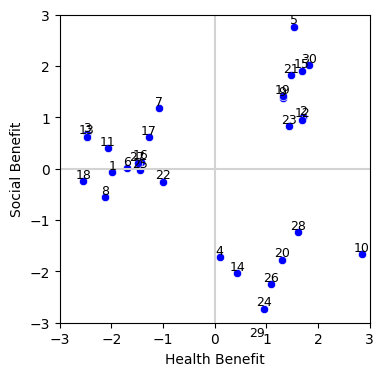

In [77]:
plt.figure(figsize=(4,4))
sns.scatterplot(x=-toothpaste_scores['health.benefit'], y=-toothpaste_scores['social.benefit'], color='blue')
plt.axvline(x=0, color='lightgrey')
plt.axhline(y=0, color='lightgrey')
for i in range(len(toothpaste_scores)):
    plt.text(x=-toothpaste_scores['health.benefit'].iloc[i],
             y=-toothpaste_scores['social.benefit'].iloc[i],
             s=toothpaste_scores['Participant'].iloc[i],
             fontsize=9, color="black", ha="center", va="bottom")
plt.xlim([-3,3])
plt.ylim([-3,3])
plt.xlabel("Health Benefit")
plt.ylabel("Social Benefit")
plt.show()

##### Principal Components Regression (PCR)

**Step 1. Original Regresion (on X1-X6)**

In [82]:
import statsmodels.api as sm

X = sm.add_constant(toothpaste_scores[['X1','X2','X3','X4','X5','X6']])
Y = toothpaste_scores['purchase_intent']

model_original = sm.OLS(Y, X).fit()
model_original.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        purchase_intent   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.892
Method:                 Least Squares   F-statistic:                     40.74
Date:              mar., 13 Ene. 2026   Prob (F-statistic):           3.99e-11
Time:                        22:12:12   Log-Likelihood:                -94.010
No. Observations:                  30   AIC:                             202.0
Df Residuals:                      23   BIC:                             211.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         69.5727     10.916      6.373      0.000      46.991      92.155
X1            -0.5469      1.586     -0.345      0.733      -3.827       2.733
X2            -1.0914      1.189     -0.918      0.368      -3.552       1.369
X3            -5.2445      1.327     -3.953      0.001      -7.989      -2.500
X4            -2.4179      1.269     -1.906      0.069      -5.042       0.206
X5             4.2176      1.268      3.326      0.003       1.594       6.841
X6             0.9197      1.318      0.698      0.492      -1.807       3.646
==============================================================================
Omnibus:                        1.529   Durbin-Watson:                   1.550
Prob(Omnibus):                  0.466   Jarque-Bera (JB):                1.173
Skew:                          -0.476   Prob(JB):                        0.556
Kurtosis:                       2.818   Cond. No.                         93.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [95]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_values = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
pd.DataFrame([vif_values], columns=X.columns, index=["VIF"])

,const,X1,X2,X3,X4,X5,X6
VIF,88.812537,7.111221,1.922292,5.364111,2.186942,4.214757,2.424


**Step 2: PCA Regression (PCR)**

In [96]:
X1 = sm.add_constant(toothpaste_scores[['health.benefit', 'social.benefit']])

model_pca = sm.OLS(Y, X1).fit()
model_pca.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        purchase_intent   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     114.1
Date:              mar., 13 Ene. 2026   Prob (F-statistic):           6.76e-14
Time:                        22:31:28   Log-Likelihood:                -97.119
No. Observations:                  30   AIC:                             200.2
Df Residuals:                      27   BIC:                             204.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             50.3429      1.186     42.454      0.000      47.910      52.776
health.benefit    -9.9562      0.718    -13.876      0.000     -11.428      -8.484
social.benefit    -4.7566      0.796     -5.974      0.000      -6.390      -3.123
==============================================================================
Omnibus:                        0.504   Durbin-Watson:                   1.783
Prob(Omnibus):                  0.777   Jarque-Bera (JB):                0.526
Skew:                          -0.274   Prob(JB):                        0.769
Kurtosis:                       2.652   Cond. No.                         1.65
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [97]:
vif_values1 = [variance_inflation_factor(X1.values, 1) for i in range(X1.shape[1])]
pd.DataFrame([vif_values1], columns=X1.columns, index=['VIF'])

,const,health.benefit,social.benefit
VIF,1.0,1.0,1.0
